## Notebook: 02_clustering_embeddings.ipynb

1. Mount Google Drive and set base paths.

2. Load the balanced dataset:
   - df_balanced.csv
   - Optionally load train_df/test_df if needed.

3. Load the RoBERTa model only if you want to filter by sentiment.
   (Not required for embeddings, but useful later.)

4. Load a Sentence-BERT model:
   - all-MiniLM-L6-v2 (fast, good)
   - or all-mpnet-base-v2 (slower, better)

5. Generate embeddings:
   - Encode all review texts.
   - Store embeddings in a numpy array.
   - Save embeddings to /embeddings/ folder.

6. Dimensionality reduction (optional but recommended):
   - Use UMAP or PCA to reduce embeddings to 2D or 10D.
   - Save reduced embeddings.

7. Clustering:
   - Try KMeans (simple baseline).
   - Try HDBSCAN (better for natural clusters).
   - Save cluster labels.

8. Analyze clusters:
   - Count reviews per cluster.
   - Extract example reviews.
   - Identify top words per cluster (optional).
   - Save cluster summaries.

9. Prepare data for summarization:
   - Group reviews by cluster.
   - Export text blocks for ChatGPT summarization.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Import required libraries
import pandas as pd
import os
from google.colab import drive

# 2. Mount Google Drive
drive.mount('/content/drive')

# 3. Define base path
path = "/content/drive/MyDrive/Amazon_Ironhack/data_balanced"

print("Files in data_balanced:")
print(os.listdir(path))

# 4. Load the balanced dataset
df_path = os.path.join(path, "df_balanced.csv")
df = pd.read_csv(df_path)

# 5. Preview the dataframe
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in data_balanced:
['df_balanced.csv', 'train_df.csv', 'test_df.csv']


,overall,reviewText,summary,asin,name,categories,text,hf_sentiment,label
0,3.0,Bought this for my mom. The touchscreen is not...,Just OK,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",Just OK. Bought this for my mom. The touchscre...,neutral,1
1,1.0,Gave as a Christmas gift. Recently learned tha...,A great gift,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",A great gift. Gave as a Christmas gift. Recent...,NaN,0
2,3.0,"It's a nice looking cover, will keep the Fire ...",attractive case - may not protect in a fall On...,B00LW9XOJM,NaN,"Cases,Kindle Store,Amazon Device Accessories,A...",attractive case - may not protect in a fall On...,neutral,1
3,1.0,Didn't know you had to buy space and many othe...,REQUIRES BUYING many things including space,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",REQUIRES BUYING many things including space. D...,NaN,0
4,5.0,I have been wanting a tablet and numerous fami...,A Great buy,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",A Great buy. I have been wanting a tablet and ...,NaN,2


## Load Sentence-BERT model

Install sentence-transformers
Import required libraries
Define base paths for dataset and embeddings
Load the balanced dataset using pandas
Extract the text column as a list
Load the Sentence-BERT model (all-MiniLM-L6-v2)
Encode all reviews into embeddings
Create embeddings directory if missing
Save embeddings as a .npy file
Print confirmation messages



In [ ]:
# ============================================
# Step 2: Generate Sentence-BERT embeddings
# ============================================

# Install sentence-transformers
!pip install -q sentence-transformers

# Imports
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import os

# Base path
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Ensure embeddings directory exists
os.makedirs(emb_path, exist_ok=True)

# Load dataset
df_path = os.path.join(base_path, "data_balanced", "df_balanced.csv")
df = pd.read_csv(df_path)

# Extract text column
if "text" in df.columns:
    reviews = df["text"].astype(str).tolist()
elif "reviewText" in df.columns:
    reviews = df["reviewText"].astype(str).tolist()
else:
    raise ValueError("No 'text' or 'reviewText' column found in dataframe.")

print("Number of reviews:", len(reviews))

# Load Sentence-BERT model
model_sbert = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded successfully.")

# Generate embeddings
embeddings = model_sbert.encode(
    reviews,
    batch_size=32,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Embeddings shape:", embeddings.shape)

# Save embeddings
emb_file = os.path.join(emb_path, "embeddings.npy")
np.save(emb_file, embeddings)

print("Saved embeddings to:", emb_file)


Number of reviews: 431


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embeddings shape: (431, 384)
Saved embeddings to: /content/drive/MyDrive/Amazon_Ironhack/embeddings/embeddings.npy


## Reduce embeddings dimensionality with UMAP

1. Install umap-learn.
2. Load embeddings.npy from /embeddings/.
3. Initialize UMAP with:
   - n_neighbors=15
   - n_components=10
   - metric="cosine"
4. Fit UMAP on embeddings.
5. Transform embeddings into reduced_embeddings.
6. Save reduced_embeddings.npy to /embeddings/.


In [ ]:
# ============================================
# Step 3: Dimensionality reduction with UMAP
# ============================================

!pip install umap-learn

import umap
import numpy as np
import os

# Base path
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Load embeddings
embeddings = np.load(os.path.join(emb_path, "embeddings.npy"))

# UMAP model
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    metric="cosine",
    random_state=42
)

# Reduce dimensions
reduced_embeddings = umap_model.fit_transform(embeddings)

print("Reduced shape:", reduced_embeddings.shape)

# Save reduced embeddings
reduced_file = os.path.join(emb_path, "reduced_embeddings.npy")
np.save(reduced_file, reduced_embeddings)

print("Saved reduced embeddings to:", reduced_file)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced shape: (431, 10)
Saved reduced embeddings to: /content/drive/MyDrive/Amazon_Ironhack/embeddings/reduced_embeddings.npy


## KMeans clustering

Import numpy, pandas, and KMeans
Define base paths
Load reduced_embeddings.npy
Set number of clusters (k = 8)
Initialize KMeans with random_state for reproducibility
Fit KMeans on reduced embeddings
Predict cluster labels
Save labels to cluster_labels_kmeans.npy
Load dataframe and add labels as a new column
Print cluster sizes using value_counts


In [ ]:
# ============================================
# Step 4: KMeans Clustering
# ============================================

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import os

# Base paths
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Load reduced embeddings
reduced_file = os.path.join(emb_path, "reduced_embeddings.npy")
reduced_embeddings = np.load(reduced_file)

print("Loaded reduced embeddings:", reduced_embeddings.shape)

# Number of clusters
k = 8

# Initialize KMeans
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Fit + predict
cluster_labels = kmeans.fit_predict(reduced_embeddings)

print("Cluster labels shape:", cluster_labels.shape)

# Save labels
labels_file = os.path.join(emb_path, "cluster_labels_kmeans.npy")
np.save(labels_file, cluster_labels)

print("Saved KMeans labels to:", labels_file)

# Load dataframe
df_path = os.path.join(base_path, "data_balanced", "df_balanced.csv")
df = pd.read_csv(df_path)

# Add labels to dataframe
df["cluster_kmeans"] = cluster_labels

# Print cluster sizes
print("Cluster sizes:")
print(df["cluster_kmeans"].value_counts())



Loaded reduced embeddings: (431, 10)
Cluster labels shape: (431,)
Saved KMeans labels to: /content/drive/MyDrive/Amazon_Ironhack/embeddings/cluster_labels_kmeans.npy
Cluster sizes:
cluster_kmeans
6    71
4    68
2    60
0    56
3    53
1    51
5    45
7    27
Name: count, dtype: int64


## HDBSCAN clustering

Install hdbscan library
Import numpy, pandas, and hdbscan
Define base paths
Load reduced_embeddings.npy

Initialize HDBSCAN with:
    min_cluster_size = 15
    min_samples = 10
    metric = "euclidean" or "cosine"

Fit HDBSCAN on reduced embeddings
Extract labels (noise = -1)
Save labels to cluster_labels_hdbscan.npy
Load dataframe and add labels as new column
Print cluster sizes using value_counts


In [ ]:
# ============================================
# Step 5: HDBSCAN Clustering
# ============================================

# Install hdbscan
!pip install -q hdbscan

import numpy as np
import pandas as pd
import hdbscan
import os

# Base paths
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Load reduced embeddings
reduced_file = os.path.join(emb_path, "reduced_embeddings.npy")
reduced_embeddings = np.load(reduced_file)

print("Loaded reduced embeddings:", reduced_embeddings.shape)

# Initialize HDBSCAN
hdb = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=10,
    metric="euclidean",   # "cosine" also works if you prefer
    cluster_selection_method="eom"
)

# Fit + extract labels
hdb.fit(reduced_embeddings)
labels_hdb = hdb.labels_

print("HDBSCAN labels shape:", labels_hdb.shape)

# Save labels
labels_file = os.path.join(emb_path, "cluster_labels_hdbscan.npy")
np.save(labels_file, labels_hdb)

print("Saved HDBSCAN labels to:", labels_file)

# Load dataframe
df_path = os.path.join(base_path, "data_balanced", "df_balanced.csv")
df = pd.read_csv(df_path)

# Add labels to dataframe
df["cluster_hdbscan"] = labels_hdb

# Print cluster sizes
print("Cluster sizes (including noise = -1):")
print(df["cluster_hdbscan"].value_counts())


Loaded reduced embeddings: (431, 10)
HDBSCAN labels shape: (431,)
Saved HDBSCAN labels to: /content/drive/MyDrive/Amazon_Ironhack/embeddings/cluster_labels_hdbscan.npy
Cluster sizes (including noise = -1):
cluster_hdbscan
 3    97
 4    80
-1    79
 0    77
 2    57
 1    41
Name: count, dtype: int64


## Load UMAP 2D embeddings or compute them
Import numpy, pandas, matplotlib
Load reduced_embeddings.npy (10D)
Load cluster labels (KMeans or HDBSCAN)
Create scatter plot with colors per cluster
Add legend and title
Show plot


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


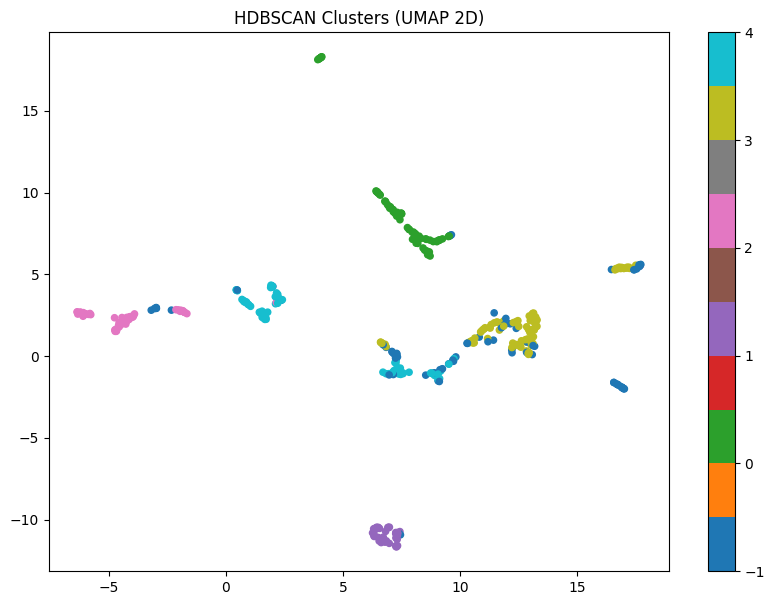

In [ ]:
# ============================================
# Step 6: 2D Visualization with UMAP
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Base paths
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Load 10D embeddings
reduced_file = os.path.join(emb_path, "reduced_embeddings.npy")
reduced_embeddings = np.load(reduced_file)

# Compute UMAP 2D
import umap

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric="cosine",
    random_state=42
).fit_transform(reduced_embeddings)

# Load HDBSCAN labels
labels_file = os.path.join(emb_path, "cluster_labels_hdbscan.npy")
labels_hdb = np.load(labels_file)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=labels_hdb,
    cmap="tab10",
    s=20
)

plt.title("HDBSCAN Clusters (UMAP 2D)")
plt.colorbar(scatter)
plt.show()


### 2D Visualization of HDBSCAN Clusters with UMAP

The plot below displays the high-dimensional embeddings reduced to two dimensions using UMAP, with each point colored according to its assigned HDBSCAN cluster. This helps to visually assess the separation and structure of the clusters.

In [ ]:
# ============================================
# Step 6: 2D Visualization with UMAP
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Base paths
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Load 10D embeddings
reduced_file = os.path.join(emb_path, "reduced_embeddings.npy")
reduced_embeddings = np.load(reduced_file)

# Compute UMAP 2D
import umap

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric="cosine",
    random_state=42
).fit_transform(reduced_embeddings)

# Load HDBSCAN labels
labels_file = os.path.join(emb_path, "cluster_labels_hdbscan.npy")
labels_hdb = np.load(labels_file)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=labels_hdb,
    cmap="tab10",
    s=20
)

plt.title("HDBSCAN Clusters (UMAP 2D)")
plt.colorbar(scatter)
plt.show()

## Load dataframe

Load HDBSCAN labels
Add labels to dataframe
Group dataframe by cluster label
For each cluster:
    extract N example reviews
Print or save examples


In [ ]:
# ============================================
# Step 7: Extract sample reviews per cluster
# ============================================

import pandas as pd
import numpy as np
import os

# Load dataframe
df_path = os.path.join(base_path, "data_balanced", "df_balanced.csv")
df = pd.read_csv(df_path)

# Load HDBSCAN labels
labels_hdb = np.load(labels_file)

# Add labels
df["cluster_hdbscan"] = labels_hdb

# Extract examples
clusters = sorted(df["cluster_hdbscan"].unique())

for c in clusters:
    print(f"\n===== Cluster {c} =====")
    examples = df[df["cluster_hdbscan"] == c]["text"].head(5).tolist()
    for ex in examples:
        print("-", ex[:200], "...")



===== Cluster -1 =====
- REQUIRES BUYING many things including space. Didn't know you had to buy space and many other things for this item to work. ...
- Easy to use, great for music. Bought this as a gift for my family, mainly to play music from Amazon. Very pleased with how easy it is to set up and use. ...
- Great item for kids. If you are looking for something inexpensive for your kids this Christmas, this is the one.Easy to operate, good quality and size for kids and adults. ...
- Small compact easy to carry. The Version with the light is the way to go. A case is a must the screen can easily be scratched. over works as intended ...
- Good for the price, but space is an issue. For $50 this is a fine tablet, However I bought a 64gb SD card to expand the storage, however i have found that a majority of apps are not able to be saved t ...

===== Cluster 0 =====
- Just ok. You get what you pay for with this kindle fire. Excellent as a Kindle for reading books, but not great for using 

## Load dataframe with cluster labels

Create output folder for cluster text files
For each cluster:
    select all reviews in that cluster
    join them with line breaks
    save to cluster_X.txt
Print confirmation


In [ ]:
# ============================================
# Step 8: Export cluster text files for summarization
# ============================================

output_dir = os.path.join(base_path, "clusters_for_summarization")
os.makedirs(output_dir, exist_ok=True)

clusters = sorted(df["cluster_hdbscan"].unique())

for c in clusters:
    cluster_reviews = df[df["cluster_hdbscan"] == c]["text"].astype(str).tolist()
    text_block = "\n".join(cluster_reviews)

    file_path = os.path.join(output_dir, f"cluster_{c}.txt")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(text_block)

    print(f"Saved cluster {c} to:", file_path)


Saved cluster -1 to: /content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_-1.txt
Saved cluster 0 to: /content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_0.txt
Saved cluster 1 to: /content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_1.txt
Saved cluster 2 to: /content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_2.txt
Saved cluster 3 to: /content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_3.txt
Saved cluster 4 to: /content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_4.txt


## Save cluster summaries

Load dataframe with cluster labels
Create an empty dictionary called cluster_summary
Get list of unique cluster labels
For each cluster:
    filter dataframe rows belonging to that cluster
    count number of reviews
    extract first 5 reviews as examples
    store count and examples in cluster_summary dictionary
Save cluster_summary dictionary as cluster_summary.json
Print confirmation



In [ ]:
# ============================================
# Step 9: Save cluster summaries to JSON
# ============================================

import pandas as pd
import numpy as np
import json
import os

# Base paths
base_path = "/content/drive/MyDrive/Amazon_Ironhack"
emb_path = os.path.join(base_path, "embeddings")

# Load dataframe
df_path = os.path.join(base_path, "data_balanced", "df_balanced.csv")
df = pd.read_csv(df_path)

# Load HDBSCAN labels
labels_file = os.path.join(emb_path, "cluster_labels_hdbscan.npy")
labels_hdb = np.load(labels_file)

# Add labels to dataframe
df["cluster_hdbscan"] = labels_hdb

# Prepare summary dictionary
cluster_summary = {}

clusters = sorted(df["cluster_hdbscan"].unique())

for c in clusters:
    cluster_df = df[df["cluster_hdbscan"] == c]

    # Extract 5 sample reviews
    examples = cluster_df["text"].astype(str).head(5).tolist()

    # Save summary
    cluster_summary[f"cluster_{c}"] = {
        "count": len(cluster_df),
        "examples": examples
    }

# Save JSON file
summary_path = os.path.join(base_path, "cluster_summary.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(cluster_summary, f, indent=4, ensure_ascii=False)

print("Saved cluster summary to:", summary_path)


Saved cluster summary to: /content/drive/MyDrive/Amazon_Ironhack/cluster_summary.json


## Merge original dataset with balanced dataset

Load original dataset
Rename Amazon columns
Keep only relevant columns
Fill NaN in summary and reviewText
Recreate text column exactly like df_balanced
Load balanced dataset
Load cluster labels
Add cluster labels to df_balanced
Merge df_balanced with df_orig on text
Print shape and preview




In [ ]:
import pandas as pd
import numpy as np
import os

base_path = "/content/drive/MyDrive/Amazon_Ironhack"

# ============================================
# Load original dataset
# ============================================

orig_path = os.path.join(base_path, "data_raw", "amazon_dataset.csv")
df_orig = pd.read_csv(orig_path, low_memory=False)

# Rename columns to match df_balanced structure
df_orig = df_orig.rename(columns={
    "reviews.rating": "overall",
    "reviews.text": "reviewText",
    "reviews.title": "summary",
    "asins": "asin"
})

# Keep only relevant columns
df_orig = df_orig[[
    "overall",
    "reviewText",
    "summary",
    "asin",
    "name",
    "categories"
]]

# ============================================
# Recreate the 'text' column EXACTLY like df_balanced
# ============================================

df_orig["summary"] = df_orig["summary"].fillna("").astype(str).str.strip()
df_orig["reviewText"] = df_orig["reviewText"].fillna("").astype(str).str.strip()

# IMPORTANT FIX:
# If summary is empty, avoid generating ". review"
df_orig["text"] = np.where(
    df_orig["summary"] == "",
    df_orig["reviewText"],                     # no summary → only reviewText
    df_orig["summary"] + ". " + df_orig["reviewText"]  # summary + ". " + reviewText
)

# ============================================
# Load balanced dataset
# ============================================

bal_path = os.path.join(base_path, "data_balanced", "df_balanced.csv")
df_bal = pd.read_csv(bal_path)

# Load cluster labels
emb_path = os.path.join(base_path, "embeddings")
df_bal["cluster_kmeans"] = np.load(os.path.join(emb_path, "cluster_labels_kmeans.npy"))
df_bal["cluster_hdbscan"] = np.load(os.path.join(emb_path, "cluster_labels_hdbscan.npy"))

# ============================================
# Merge using the 'text' column
# ============================================

df_merged = df_bal.merge(
    df_orig,
    on="text",
    how="left"
)

print("Merged shape:", df_merged.shape)
df_merged.head()


Merged shape: (431, 17)


,overall_x,reviewText_x,summary_x,asin_x,name_x,categories_x,text,hf_sentiment,label,cluster_kmeans,cluster_hdbscan,overall_y,reviewText_y,summary_y,asin_y,name_y,categories_y
0,3.0,Bought this for my mom. The touchscreen is not...,Just OK,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",Just OK. Bought this for my mom. The touchscre...,neutral,1,1,4,3.0,Bought this for my mom. The touchscreen is not...,Just OK,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T..."
1,1.0,Gave as a Christmas gift. Recently learned tha...,A great gift,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",A great gift. Gave as a Christmas gift. Recent...,NaN,0,4,4,1.0,Gave as a Christmas gift. Recently learned tha...,A great gift,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T..."
2,3.0,"It's a nice looking cover, will keep the Fire ...",attractive case - may not protect in a fall On...,B00LW9XOJM,NaN,"Cases,Kindle Store,Amazon Device Accessories,A...",attractive case - may not protect in a fall On...,neutral,1,0,3,3.0,"It's a nice looking cover, will keep the Fire ...",attractive case - may not protect in a fall On...,B00LW9XOJM,NaN,"Cases,Kindle Store,Amazon Device Accessories,A..."
3,1.0,Didn't know you had to buy space and many othe...,REQUIRES BUYING many things including space,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",REQUIRES BUYING many things including space. D...,NaN,0,4,-1,1.0,Didn't know you had to buy space and many othe...,REQUIRES BUYING many things including space,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T..."
4,5.0,I have been wanting a tablet and numerous fami...,A Great buy,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",A Great buy. I have been wanting a tablet and ...,NaN,2,0,3,5.0,I have been wanting a tablet and numerous fami...,A Great buy,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T..."


## Clean merged dataframe after merge

Identify columns ending with "_x"
Drop those columns
Identify columns ending with "_y"
Rename them by removing "_y"
Keep text, label, cluster_kmeans, cluster_hdbscan
Reorder columns for clarity
Print final dataframe shape and head



In [ ]:
# ============================================
# Step 10: Clean merged dataframe
# ============================================

# 1. Drop *_x columns (from df_balanced)
cols_to_drop = [col for col in df_merged.columns if col.endswith("_x")]
df_clean = df_merged.drop(columns=cols_to_drop)

# 2. Rename *_y columns (from original dataset)
df_clean = df_clean.rename(columns={
    "overall_y": "overall",
    "reviewText_y": "reviewText",
    "summary_y": "summary",
    "asin_y": "asin",
    "name_y": "name",
    "categories_y": "categories"
})

# 3. Drop leftover *_y columns if any remain
cols_to_drop_y = [col for col in df_clean.columns if col.endswith("_y")]
df_clean = df_clean.drop(columns=cols_to_drop_y)

# 4. Reorder columns for clarity
df_clean = df_clean[[
    "overall",
    "reviewText",
    "summary",
    "asin",
    "name",
    "categories",
    "text",
    "label",
    "cluster_kmeans",
    "cluster_hdbscan"
]]

print("Final cleaned dataframe shape:", df_clean.shape)
df_clean.head()


Final cleaned dataframe shape: (431, 10)


,overall,reviewText,summary,asin,name,categories,text,label,cluster_kmeans,cluster_hdbscan
0,3.0,Bought this for my mom. The touchscreen is not...,Just OK,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",Just OK. Bought this for my mom. The touchscre...,1,1,4
1,1.0,Gave as a Christmas gift. Recently learned tha...,A great gift,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",A great gift. Gave as a Christmas gift. Recent...,0,4,4
2,3.0,"It's a nice looking cover, will keep the Fire ...",attractive case - may not protect in a fall On...,B00LW9XOJM,NaN,"Cases,Kindle Store,Amazon Device Accessories,A...",attractive case - may not protect in a fall On...,1,0,3
3,1.0,Didn't know you had to buy space and many othe...,REQUIRES BUYING many things including space,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",REQUIRES BUYING many things including space. D...,0,4,-1
4,5.0,I have been wanting a tablet and numerous fami...,A Great buy,B018Y229OU,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Fire Tablets,Tablets,Computers & Tablets,All T...",A Great buy. I have been wanting a tablet and ...,2,0,3


## Build a dictionary with basic information for each KMeans cluster.

Load df_merged
Initialize empty dictionary cluster_summary
Get unique cluster IDs from cluster_kmeans

For each cluster_id:
    Filter rows belonging to that cluster
    Compute cluster size
    Extract 5 sample reviews
    Compute average rating
    Compute top 5 products by frequency
    Store everything in cluster_summary[cluster_id]
    
Save cluster_summary as JSON



In [ ]:
# ============================================
# Step 11: Build KMeans cluster summary dictionary (FIXED)
# ============================================

import pandas as pd
import numpy as np
import json
import os

df = df_clean.copy()

cluster_summary = {}

clusters = sorted(df["cluster_kmeans"].unique())

for cluster_id in clusters:
    df_cluster = df[df["cluster_kmeans"] == cluster_id]

    size = len(df_cluster)
    sample_reviews = df_cluster["text"].astype(str).head(5).tolist()
    avg_rating = df_cluster["overall"].mean()

    top_products = (
        df_cluster["name"]
        .value_counts()
        .head(5)
        .to_dict()
    )

    # FIX: convert cluster_id to string
    cluster_summary[str(cluster_id)] = {
        "size": size,
        "avg_rating": float(avg_rating),
        "sample_reviews": sample_reviews,
        "top_products": top_products
    }

# Save JSON
output_path = os.path.join(base_path, "cluster_summary_kmeans.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(cluster_summary, f, indent=4, ensure_ascii=False)

print("Saved cluster summary to:", output_path)


Saved cluster summary to: /content/drive/MyDrive/Amazon_Ironhack/cluster_summary_kmeans.json


## Top 3 best products

Start from df_clean with columns:
    categories, name, overall

Group by category and product name:
    compute:
        - average rating (mean of overall)
        - number of reviews (count of overall)

Optionally filter out products with very few reviews (e.g., min_reviews = 3)

For each category:
    sort products by:
        1) average rating (descending)
        2) number of reviews (descending)
    take top 3 products

Store result in a dataframe or dictionary for later use
Print or inspect top products per category


In [ ]:
# ============================================
# Step 1: Top 3 best products per category
# ============================================

import pandas as pd

df = df_clean.copy()

# Optional: minimum number of reviews per product to be considered
min_reviews = 3

# 1. Aggregate by category and product name
grouped = (
    df.groupby(["categories", "name"], as_index=False)
      .agg(
          avg_rating=("overall", "mean"),
          review_count=("overall", "count")
      )
)

# 2. Filter products with too few reviews (optional but recommended)
grouped = grouped[grouped["review_count"] >= min_reviews]

# 3. Sort within each category and take top 3
grouped_sorted = grouped.sort_values(
    by=["categories", "avg_rating", "review_count"],
    ascending=[True, False, False]
)

top3_per_category = (
    grouped_sorted
    .groupby("categories", as_index=False)
    .head(3)
)

print("Top 3 best products per category (by average rating):")
top3_per_category.head(20)


Top 3 best products per category (by average rating):


,categories,name,avg_rating,review_count
1,"Amazon Devices & Accessories,Amazon Device Acc...","All-New Kindle E-reader - Black, 6 Glare-Free ...",2.833333,12
2,"Amazon Devices & Accessories,Amazon Device Acc...",Amazon 5W USB Official OEM Charger and Power A...,2.142857,7
4,"Computers/Tablets & Networking,Tablets & eBook...",Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,3.250000,16
6,"Electronics Features,Fire Tablets,Computers & ...","Echo (White),,,\r\nEcho (White),,,",2.333333,6
9,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",3.400000,30
14,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",3.129496,139
16,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Amazon - Amazon Tap Portable Bluetooth and Wi-...,4.500000,4
19,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",3.387097,31
18,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",3.133333,30
21,"Tablets,Fire Tablets,Computers & Tablets,All T...",Amazon Kindle Paperwhite - eBook reader - 4 GB...,3.666667,9


## Top 2 worst products

Start from df_clean with columns:
    categories, name, overall

Group by category and product name:
    compute:
        - average rating
        - number of reviews

Filter out products with too few reviews (optional)

For each category:
    sort products by:
        1) average rating (ascending)
        2) number of reviews (descending)
    take bottom 3 products

Store results in a dataframe or dictionary


In [ ]:
# ============================================
# Step 2: Top 3 worst products per category
# ============================================

import pandas as pd

df = df_clean.copy()

# Optional: minimum number of reviews per product
min_reviews = 3

# 1. Aggregate by category and product name
grouped = (
    df.groupby(["categories", "name"], as_index=False)
      .agg(
          avg_rating=("overall", "mean"),
          review_count=("overall", "count")
      )
)

# 2. Filter products with too few reviews
grouped = grouped[grouped["review_count"] >= min_reviews]

# 3. Sort within each category (ascending rating = worst first)
grouped_sorted = grouped.sort_values(
    by=["categories", "avg_rating", "review_count"],
    ascending=[True, True, False]
)

# 4. Take bottom 3 per category
worst3_per_category = (
    grouped_sorted
    .groupby("categories", as_index=False)
    .head(3)
)

print("Top 3 worst products per category (by average rating):")
worst3_per_category.head(20)


Top 3 worst products per category (by average rating):


,categories,name,avg_rating,review_count
2,"Amazon Devices & Accessories,Amazon Device Acc...",Amazon 5W USB Official OEM Charger and Power A...,2.142857,7
1,"Amazon Devices & Accessories,Amazon Device Acc...","All-New Kindle E-reader - Black, 6 Glare-Free ...",2.833333,12
4,"Computers/Tablets & Networking,Tablets & eBook...",Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,3.250000,16
6,"Electronics Features,Fire Tablets,Computers & ...","Echo (White),,,\r\nEcho (White),,,",2.333333,6
9,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",3.400000,30
14,"Fire Tablets,Tablets,Computers & Tablets,All T...","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",3.129496,139
18,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",3.133333,30
19,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Echo (White),,,\r\nEcho (White),,,",3.387097,31
16,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Amazon - Amazon Tap Portable Bluetooth and Wi-...,4.500000,4
22,"Tablets,Fire Tablets,Computers & Tablets,All T...","Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",3.421053,19


## Category resume

Start from df_clean with columns:
    categories, overall, text, name

Get unique categories

Initialize category_summary = {}

For each category:
    filter df_cat = rows where categories == category

    compute:
        - avg_rating = mean(overall)
        - total_reviews = count(overall)
        - top_products = most common product names
        - positive_examples = top 5 reviews with rating >= 4
        - negative_examples = top 5 reviews with rating <= 2

    build entry:
        category_summary[category] = {
            "avg_rating": avg_rating,
            "total_reviews": total_reviews,
            "top_products": top_products,
            "positive_examples": positive_examples,
            "negative_examples": negative_examples
        }

Save category_summary for LLM summarization


In [ ]:
# ============================================
# Step 3: Category-level summary dictionary
# ============================================

import pandas as pd
import numpy as np

df = df_clean.copy()

category_summary = {}

categories = sorted(df["categories"].unique())

for cat in categories:
    df_cat = df[df["categories"] == cat]

    # Basic stats
    avg_rating = df_cat["overall"].mean()
    total_reviews = len(df_cat)

    # Top products
    top_products = (
        df_cat["name"]
        .value_counts()
        .head(5)
        .to_dict()
    )

    # Positive examples (rating >= 4)
    positive_examples = (
        df_cat[df_cat["overall"] >= 4]["text"]
        .astype(str)
        .head(5)
        .tolist()
    )

    # Negative examples (rating <= 2)
    negative_examples = (
        df_cat[df_cat["overall"] <= 2]["text"]
        .astype(str)
        .head(5)
        .tolist()
    )

    # Build dictionary entry
    category_summary[cat] = {
        "avg_rating": float(avg_rating),
        "total_reviews": total_reviews,
        "top_products": top_products,
        "positive_examples": positive_examples,
        "negative_examples": negative_examples
    }

print("Category summary ready.")
list(category_summary.items())[:3]  # preview


Category summary ready.


[('Amazon Device Accessories,Kindle Store,Kindle Touch (4th Generation) Accessories,Kindle E-Reader Accessories,Covers,Kindle Touch (4th Generation) Covers',
  {'avg_rating': 3.0,
   'total_reviews': 1,
   'top_products': {'Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case': 1},
   'positive_examples': [],
   'negative_examples': []}),
 ('Amazon Devices & Accessories,Amazon Device Accessories,Power Adapters & Cables,Kindle Store,Kindle E-Reader Accessories,Kindle Paperwhite Accessories',
  {'avg_rating': 2.5789473684210527,
   'total_reviews': 19,
   'top_products': {'All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi -  Includes Special Offers,,': 12,
    'Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,\r\nAmazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,': 7},
   'positive_examples': ['Five Stars. Kindle was no longer charging properly and this solved th

## Function build_prompt_cluster(cluster):
    Extract:
        - cluster_id
        - size
        - avg_rating
        - sentiment counts (positive, neutral, negative)
        - top_products
        - sample_reviews

    Build a multi-section prompt:
        - context and instructions
        - cluster metadata
        - sample reviews
        - strict tasks
        - strict output format

    Return the final prompt string


## Function build_prompt_product(product):
    Extract:
        - product_name
        - category
        - review_count
        - avg_rating
        - top_themes
        - sample_reviews

    Build a structured prompt:
        - context and instructions
        - product metadata
        - sample reviews
        - strict tasks
        - strict output format

    Return the final prompt string


## Function build_prompt_category(category):
    Extract:
        - category_name
        - total_reviews
        - avg_rating
        - top_products
        - positive_examples
        - negative_examples

    Build a structured prompt:
        - context and instructions
        - category metadata
        - sample reviews
        - strict tasks
        - strict output format

    Return the final prompt string


### Load or create example dictionaries:
    - example_cluster
    - example_product
    - example_category

2. Call:
    - build_prompt_cluster(example_cluster)
    - build_prompt_product(example_product)
    - build_prompt_category(example_category)

3. Print each prompt with separators


In [ ]:
edge_all_open_tabs = None

def build_prompt_cluster(cluster):
    cluster_id = cluster["cluster_id"]
    size = cluster["size"]
    avg_rating = cluster["avg_rating"]

    pos = cluster.get("positive_count", 0)
    neu = cluster.get("neutral_count", 0)
    neg = cluster.get("negative_count", 0)

    top_products = cluster["top_products"]
    sample_reviews = cluster["sample_reviews"]

    prompt = f"""
You are an expert analyst specializing in customer behavior, product perception, and sentiment interpretation across large review datasets.

You will receive metadata and sample reviews for a single review cluster.
Each cluster groups together reviews that share similar themes, tone, and user motivations.

Use ONLY the information provided.
Do NOT copy review text verbatim.
Do NOT invent product features, experiences, or motivations not supported by the evidence.
Do NOT generalize beyond what the data shows.
Every statement must be grounded in patterns that appear in the sample reviews or metadata.

Your output will be used in a cluster‑level dashboard, so consistency, clarity, and analytical depth are essential.
Focus on recurring themes, not isolated comments.
Avoid vague or generic statements; be specific and analytical.
Avoid clichés such as “customers appreciate quality” or “users expect reliability.”

------------------------------------------------------------
CLUSTER DATA
- Cluster ID: {cluster_id}
- Total reviews: {size}
- Average rating: {avg_rating:.2f}

TOP PRODUCTS MENTIONED:
{chr(10).join(f"- {p}" for p in top_products)}

SENTIMENT DISTRIBUTION:
- Positive: {pos}
- Neutral: {neu}
- Negative: {neg}

SAMPLE REVIEWS (evidence):
{chr(10).join(f"- {r}" for r in sample_reviews)}
------------------------------------------------------------

YOUR TASKS (STRICT):

1. CLUSTER NAME (3–6 words)

2. CLUSTER SUMMARY (4–6 sentences)
Explain:
- main themes
- what users value
- what frustrates them
- unmet expectations
- patterns that define this cluster
Use evidence from the reviews without quoting them.

3. SENTIMENT ANALYSIS
Positive:
- reasons
Negative:
- reasons
Neutral:
- reasons

4. TOP 3 PRODUCT SUMMARIES
For each product:
- 2–3 sentence summary
- what customers like
- what customers dislike
- ideal user

5. ACTIONABLE INSIGHTS (3–5 items)
Insights must be:
- specific
- evidence‑based
- actionable

------------------------------------------------------------
OUTPUT FORMAT (STRICT):

Cluster {cluster_id}
Name: {{3–6 word title}}

Summary:
{{4–6 sentences}}

Sentiment Analysis:
Positive:
- {{reason}}
Negative:
- {{reason}}
Neutral:
- {{reason}}

Top Products:
1. {{Product Name}}
   {{summary}}

2. {{Product Name}}
   {{summary}}

3. {{Product Name}}
   {{summary}}

Actionable Insights:
- {{insight}}
- {{insight}}
- {{insight}}
------------------------------------------------------------
"""
    return prompt.strip()



def build_prompt_product(product):
    product_name = product["name"]
    category = product["category"]
    review_count = product["review_count"]
    avg_rating = product["avg_rating"]

    top_themes = product.get("top_themes", [])
    sample_reviews = product["sample_reviews"]

    prompt = f"""
You are an expert product analyst specializing in customer behavior, product perception, and sentiment interpretation across large review datasets.

You will receive metadata and sample reviews for a single product.
Your job is to produce a structured, evidence‑based summary of the product.

Use ONLY the information provided.
Do NOT copy review text verbatim.
Do NOT invent product features, technical specifications, or experiences not supported by the evidence.
Do NOT use generic marketing language.
Avoid clichés such as “high quality” or “great performance.”
Every insight must be grounded in patterns that appear repeatedly in the sample reviews or metadata.

Your output will be used in a product‑level dashboard, so clarity, structure, and consistency are essential.
Focus on recurring themes, not isolated comments.
Avoid vague or generic statements; be specific and analytical.

------------------------------------------------------------
PRODUCT DATA
- Product name: {product_name}
- Category: {category}
- Total reviews analyzed: {review_count}
- Average rating: {avg_rating:.2f}

TOP THEMES:
{chr(10).join(f"- {t}" for t in top_themes)}

SAMPLE REVIEWS (evidence):
{chr(10).join(f"- {r}" for r in sample_reviews)}
------------------------------------------------------------

YOUR TASKS (STRICT):

1. PRODUCT SUMMARY (4–6 sentences)

2. POSITIVE INSIGHTS (3–5 bullet points)
Each bullet must reflect a recurring pattern.

3. NEGATIVE INSIGHTS (3–5 bullet points)
Each bullet must reflect a recurring pattern.

4. IDEAL USER PROFILE (2–3 sentences)
Describe the type of customer who benefits most from this product.

5. ACTIONABLE RECOMMENDATIONS (3–5 items)
Insights must be:
- specific
- evidence‑based
- actionable

------------------------------------------------------------
OUTPUT FORMAT (STRICT):

Product: {product_name}

Summary:
{{4–6 sentences}}

Positive Insights:
- {{reason}}

Negative Insights:
- {{reason}}

Ideal User:
{{2–3 sentences}}

Actionable Recommendations:
- {{recommendation}}
- {{recommendation}}
- {{recommendation}}
------------------------------------------------------------
"""
    return prompt.strip()



def build_prompt_category(category):
    category_name = category["category_name"]
    total_reviews = category["total_reviews"]
    avg_rating = category["avg_rating"]

    top_products = category["top_products"]
    positive_examples = category["positive_examples"]
    negative_examples = category["negative_examples"]

    prompt = f"""
You are an expert market analyst specializing in customer behavior, product perception, and sentiment interpretation across large review datasets.

You will receive metadata and sample reviews for a single product category.
Your job is to produce a structured, evidence‑based summary of the category that highlights real patterns in user experience.

Use ONLY the information provided.
Do NOT copy review text verbatim.
Do NOT invent product features, market trends, or user motivations not supported by the evidence.
Do NOT generalize beyond what the data shows.
Every statement must be grounded in patterns that appear in the sample reviews or metadata.

Your output will be used in a category‑level dashboard, so consistency, clarity, and analytical depth are essential.
Focus on recurring themes, not isolated comments.
Avoid vague or generic statements; be specific and analytical.
Avoid clichés such as “customers appreciate quality” or “users expect reliability.”

------------------------------------------------------------
CATEGORY DATA
- Category name: {category_name}
- Total reviews analyzed: {total_reviews}
- Average rating: {avg_rating:.2f}

TOP PRODUCTS IN THIS CATEGORY:
{chr(10).join(f"- {p}" for p in top_products)}

POSITIVE REVIEW EXAMPLES (evidence):
{chr(10).join(f"- {r}" for r in positive_examples)}

NEGATIVE REVIEW EXAMPLES (evidence):
{chr(10).join(f"- {r}" for r in negative_examples)}
------------------------------------------------------------

YOUR TASKS (STRICT):

1. CATEGORY SUMMARY (5–7 sentences)
Explain:
- what customers appreciate
- what customers dislike
- unmet expectations
- recurring patterns
- overall satisfaction
Use evidence from the examples without quoting them.

2. POSITIVE THEMES (3–5 bullet points)
Each bullet must reflect a recurring pattern.

3. NEGATIVE THEMES (3–5 bullet points)
Each bullet must reflect a recurring pattern.

4. CATEGORY INSIGHTS (3–5 items)
Insights must be:
- specific
- evidence‑based
- actionable

5. MARKET POSITIONING SUMMARY (2–3 sentences)
Describe:
- how the category is perceived
- what type of customer it attracts

------------------------------------------------------------
OUTPUT FORMAT (STRICT):

Category: {category_name}

Summary:
{{5–7 sentences}}

Positive Themes:
- {{theme}}

Negative Themes:
- {{theme}}

Category Insights:
- {{insight}}

Market Positioning:
{{2–3 sentences}}
------------------------------------------------------------
"""
    return prompt.strip()


example_category = {
    "category_name": "Electronics",
    "total_reviews": 540,
    "avg_rating": 4.1,
    "top_products": ["Headphones X", "Smartwatch Y", "Camera Z"],
    "positive_examples": [
        "Battery life exceeded expectations.",
        "Very intuitive and easy to use."
    ],
    "negative_examples": [
        "Stopped working after two weeks.",
        "Build quality feels cheap."
    ]
}

print("===== CLUSTER PROMPT =====\n")
print(build_prompt_cluster(example_cluster))

print("\n\n===== PRODUCT PROMPT =====\n")
print(build_prompt_product(example_product))

print("\n\n===== CATEGORY PROMPT =====\n")
print(build_prompt_category(example_category))



===== CLUSTER PROMPT =====

You are an expert analyst specializing in customer behavior, product perception, and sentiment interpretation across large review datasets.

You will receive metadata and sample reviews for a single review cluster.  
Each cluster groups together reviews that share similar themes, tone, and user motivations.

Use ONLY the information provided.  
Do NOT copy review text verbatim.  
Do NOT invent product features, experiences, or motivations not supported by the evidence.  
Do NOT generalize beyond what the data shows.  
Every statement must be grounded in patterns that appear in the sample reviews or metadata.

Your output will be used in a cluster‑level dashboard, so consistency, clarity, and analytical depth are essential.  
Focus on recurring themes, not isolated comments.  
Avoid vague or generic statements; be specific and analytical.  
Avoid clichés such as “customers appreciate quality” or “users expect reliability.”

-----------------------------------

## Train clustering model with embeddings

1. Load the reviews dataset from CSV (or JSON).
2. Select the text column that contains the review text.
3. Load a SentenceTransformer model (e.g., MiniLM).
4. Encode all review texts into embeddings using the model.
5. Choose the number of clusters (k), for example between 4 and 6.
6. Initialize a KMeans model with k clusters and a fixed random_state.
7. Fit KMeans on the embeddings and get the cluster labels.
8. Add the cluster labels as a new column "cluster_id" to the dataframe.
9. Save the updated dataframe with the cluster_id column to a new file.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Amazon_Ironhack"


 clusters_for_summarization    data_clean   notebooks
 cluster_summary.json	       data_raw    'Nuevo Sentiment Proyecto.gdoc'
 cluster_summary_kmeans.json   embeddings   streamlit_app
 data_balanced		       models


In [ ]:
import pandas as pd

# 1. Define the correct file path
file_path = "/content/drive/MyDrive/Amazon_Ironhack/data_raw/amazon_dataset.csv"

# 2. Load the dataset
df = pd.read_csv(file_path)

# 3. Verify the dataframe
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Shape: (34660, 21)
Columns: ['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


/tmp/ipykernel_2074/1327160362.py:7: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


## Prepare the review text column

1. Select the column "reviews.text" from the dataframe.
2. Remove rows where the text is missing or empty.
3. Optionally rename the column to "review_text" for convenience.
4. Convert the text column into a Python list.
5. Print the number of valid reviews to confirm the data is ready.


In [ ]:
# 1. Select the review text column
df = df.rename(columns={"reviews.text": "review_text"})

# 2. Remove rows with missing or empty text
df = df[df["review_text"].notna()]
df = df[df["review_text"].str.strip() != ""]

# 3. Convert to list
review_texts = df["review_text"].astype(str).tolist()

# 4. Verify
print("Number of valid reviews:", len(review_texts))


Number of valid reviews: 34659


## Generate semantic embeddings for all reviews

1. Load a SentenceTransformer model (e.g., MiniLM).
2. Encode all review texts using model.encode().
3. Use a reasonable batch size (e.g., 32) to avoid memory issues.
4. Store the resulting embeddings in a NumPy array.
5. Print the shape of the embeddings to confirm they were generated correctly.
6. (Optional) Save the embeddings to disk for reuse.


In [ ]:
from sentence_transformers import SentenceTransformer

# 1. Load the model
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# 2. Generate embeddings
embeddings = model.encode(
    review_texts,
    batch_size=32,
    show_progress_bar=True
)

# 3. Verify
print("Embeddings shape:", embeddings.shape)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1084 [00:00<?, ?it/s]

Embeddings shape: (34659, 384)


## Train the clustering model using the embeddings

1. Choose the number of clusters (k), usually between 4 and 6.
2. Initialize a KMeans model with k clusters and a fixed random_state.
3. Fit the KMeans model on the embeddings.
4. Predict the cluster label for each review.
5. Add the cluster labels to the dataframe as a new column "cluster_id".
6. Print the number of reviews per cluster to verify distribution.


In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# 1. Choose number of clusters
k = 5  # you can try 4, 5, 6 later

# 2. Initialize KMeans
kmeans = KMeans(n_clusters=k, random_state=42)

# 3. Fit the model
kmeans.fit(embeddings)

# 4. Predict cluster labels
cluster_labels = kmeans.labels_

# 5. Add cluster_id to the dataframe
df["cluster_id"] = cluster_labels

# 6. Check distribution
print(df["cluster_id"].value_counts())


cluster_id
2    10062
0     8350
1     7049
4     4804
3     4394
Name: count, dtype: int64


## Analyze each cluster and extract useful information

1. Group the dataframe by "cluster_id".
2. For each cluster:
    a. Extract all reviews belonging to that cluster.
    b. Compute the average rating.
    c. Count how many reviews each product_id (or ASIN) has.
    d. Select the top products based on frequency.
    e. Select a few representative reviews (e.g., first 3).
3. Store all extracted information in a dictionary.
4. Save the dictionary for later LLM summarization.


In [ ]:
import numpy as np

cluster_info = {}

# 1. Group by cluster_id
grouped = df.groupby("cluster_id")

for cluster_id, group in grouped:

    # a. Extract reviews
    reviews = group["review_text"].tolist()

    # b. Average rating
    avg_rating = group["reviews.rating"].mean()

    # c. Top products (using ASINs)
    top_products = (
        group["asins"]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )

    # d. Representative reviews (first 3)
    sample_reviews = reviews[:3]

    # e. Store info
    cluster_info[cluster_id] = {
        "cluster_id": cluster_id,
        "size": len(group),
        "avg_rating": float(avg_rating),
        "top_products": top_products,
        "sample_reviews": sample_reviews
    }

# 4. Verify
cluster_info


{0: {'cluster_id': 0,
  'size': 8350,
  'avg_rating': 4.660675772825305,
  'top_products': ['B018Y229OU',
   'B00L9EPT8O,B01E6AO69U',
   'B00U3FPN4U',
   'B01AHB9CN2',
   'B018Y23MNM'],
  'sample_reviews': ['This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.',
   'great for beginner or experienced person. Bought as a gift and she loves it',
   'I gave this as a Christmas gift to my inlaws, husband and uncle. They loved it and how easy they are to use with fantastic features!']},
 1: {'cluster_id': 1,
  'size': 7049,
  'avg_rating': 4.489572989076465,
  'top_products': ['B018Y229OU',
   'B01AHB9CN2',
   'B018Y23MNM',
   'B018Y225IA',
   'B00TSUGXKE'],
  'sample_reviews': ['Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...',
   "I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are P

## Assign human-readable names to each cluster

1. For each cluster:
    a. Inspect the top products.
    b. Inspect the representative reviews.
    c. Identify the main theme of the cluster.
2. Create a mapping from cluster_id to a descriptive name.
3. Add a new column "cluster_name" to the dataframe.
4. Store the mapping for later use in LLM prompts.


In [ ]:
cluster_names = {
    0: "Kids & Family Tablets",
    1: "Entertainment & Media Tablets",
    2: "General Use Tablets",
    3: "Alexa Companion Tablets",
    4: "Reading & E‑books Tablets"
}

# Add names to the dataframe
df["cluster_name"] = df["cluster_id"].map(cluster_names)

# Verify
df[["cluster_id", "cluster_name"]].head()


,cluster_id,cluster_name
0,0,Kids & Family Tablets
1,0,Kids & Family Tablets
2,1,Entertainment & Media Tablets
3,1,Entertainment & Media Tablets
4,1,Entertainment & Media Tablets


In [ ]:
df[["cluster_id", "cluster_name"]].drop_duplicates().sort_values("cluster_id")


,cluster_id,cluster_name
0,0,Kids & Family Tablets
2,1,Entertainment & Media Tablets
10,2,General Use Tablets
210,3,Alexa Companion Tablets
6,4,Reading & E‑books Tablets


## Build clean JSON structures for each cluster

1. Create a dictionary where each key is a cluster_id.
2. For each cluster:
    a. Include the cluster name.
    b. Include the top products.
    c. Include the average rating.
    d. Include representative reviews.
3. Save the dictionary as a JSON file in clusters_for_summarization/.
4. This JSON will be the input for the LLM summarization step.


In [ ]:
import json
import os

output_path = "/content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization"

# Ensure folder exists
os.makedirs(output_path, exist_ok=True)

# Build final JSON structure
final_clusters = {}

for cid, info in cluster_info.items():
    final_clusters[cid] = {
        "cluster_id": cid,
        "cluster_name": cluster_names[cid],
        "size": info["size"],
        "avg_rating": info["avg_rating"],
        "top_products": info["top_products"],
        "sample_reviews": info["sample_reviews"]
    }

# Save JSON
json_path = os.path.join(output_path, "cluster_summary.json")

with open(json_path, "w") as f:
    json.dump(final_clusters, f, indent=4)

json_path


'/content/drive/MyDrive/Amazon_Ironhack/clusters_for_summarization/cluster_summary.json'

## Generate summaries using the LLM

1. Load cluster_summary.json.
2. For each cluster:
    a. Extract cluster_name, top_products, sample_reviews, avg_rating.
    b. Build a clean prompt for the LLM.
    c. Call the LLM to generate a summary.
    d. Store the summary in a dictionary.
3. Save all summaries to cluster_summary_kmeans.json.


In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPEN_API_KEY")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import joblib
import os

# Paths
BASE = "/content/drive/MyDrive/Amazon_Ironhack/clustering_pipeline"
EMB_PATH = f"{BASE}/embeddings/embeddings.npy"
MODEL_PATH = f"{BASE}/models/kmeans.pkl"

# Load embeddings
embeddings = np.load(EMB_PATH)

# Number of clusters (you used 5)
n_clusters = 5

# Train model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(embeddings)

# Save model
os.makedirs(f"{BASE}/models", exist_ok=True)
joblib.dump(kmeans, MODEL_PATH)

print("kmeans.pkl saved to:", MODEL_PATH)


kmeans.pkl saved to: /content/drive/MyDrive/Amazon_Ironhack/clustering_pipeline/models/kmeans.pkl
